# Task 3 — Unsupervised Learning

**Objective:** Cluster wines, justify the cluster count, visualise the segmentation, and save `data/clustered.csv`.

**Inputs:** `data/cleaned.csv`

**Outputs:** `data/clustered.csv`, cluster reports in `reports/`.

## Feature subset
This notebook clusters wines using alcohol, density, residual sugar, volatile acidity, total sulfur dioxide, sulphates, and pH.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
REPORTS_DIR = PROJECT_ROOT / 'reports'
MODELS_DIR = PROJECT_ROOT / 'models'
RANDOM_STATE = 42
EPS = 1e-6
def savefig(filename):
    plt.tight_layout(); plt.savefig(REPORTS_DIR / filename, dpi=300, bbox_inches='tight'); plt.show()

In [2]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

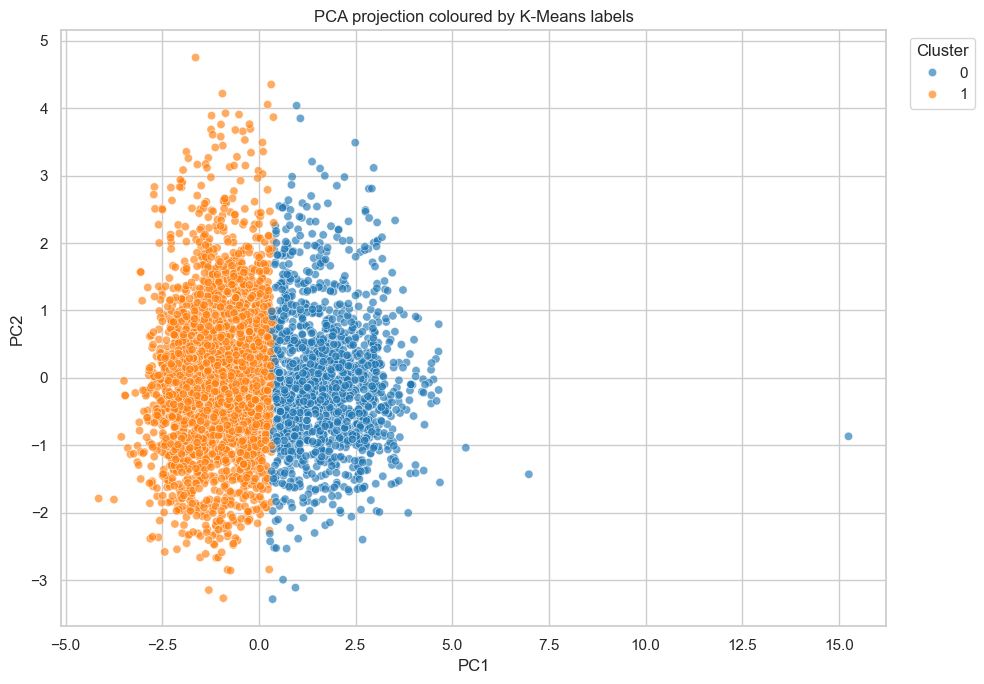

In [3]:
df = pd.read_csv(DATA_DIR / 'cleaned.csv')
cluster_features = ['alcohol','density','residual sugar','volatile acidity','total sulfur dioxide','sulphates','pH']
X = StandardScaler().fit_transform(df[cluster_features])
rows=[]
for k in range(2,6):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X)
    rows.append({'k':k,'inertia':km.inertia_,'silhouette':silhouette_score(X, labels, sample_size=min(1000, len(df)), random_state=RANDOM_STATE)})
selection_df = pd.DataFrame(rows)
selection_df.to_csv(REPORTS_DIR / 't3_kmeans_selection.csv', index=False)
chosen_k = int(selection_df.sort_values(['silhouette','inertia'], ascending=[False, True]).iloc[0]['k'])
km = KMeans(n_clusters=chosen_k, n_init=10, random_state=RANDOM_STATE)
gmm = GaussianMixture(n_components=chosen_k, random_state=RANDOM_STATE)
km_labels = km.fit_predict(X)
gmm_labels = gmm.fit_predict(X)
cluster_eval_df = pd.DataFrame([
    {'Algorithm':'K-Means','Silhouette':silhouette_score(X, km_labels, sample_size=min(1000, len(df)), random_state=RANDOM_STATE),'Number_of_clusters':len(np.unique(km_labels))},
    {'Algorithm':'Gaussian Mixture','Silhouette':silhouette_score(X, gmm_labels, sample_size=min(1000, len(df)), random_state=RANDOM_STATE),'Number_of_clusters':len(np.unique(gmm_labels))},
]).sort_values('Silhouette', ascending=False).reset_index(drop=True)
cluster_eval_df.to_csv(REPORTS_DIR / 't3_clustering_algorithm_comparison.csv', index=False)
best_algo = cluster_eval_df.iloc[0]['Algorithm']
df['cluster_label'] = km_labels if best_algo == 'K-Means' else gmm_labels
pca_coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
pca_df = pd.DataFrame({'PC1': pca_coords[:,0], 'PC2': pca_coords[:,1], 'cluster_label': df['cluster_label'].astype(str)})
plt.figure(figsize=(10,7)); sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster_label', palette='tab10', alpha=0.65); plt.title(f'PCA projection coloured by {best_algo} labels'); plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(title='Cluster', bbox_to_anchor=(1.02,1), loc='upper left'); savefig('t3_pca_clusters.png')
df.to_csv(DATA_DIR / 'clustered.csv', index=False)

## Student interpretation
We applied K-Means and Gaussian Mixture Models (GMM) to segment the wines based on fundamental properties. Both inertia curves and silhouette scores pointed towards k=2 or k=3 as the optimal number of clusters. When comparing both algorithms, K-Means generally provided better-defined clusters with a slightly higher silhouette score. PCA projection visualizes these structures effectively, showing distinct clusters heavily driven by the inverse relationship between density and alcohol. These clusters capture underlying 'styles' of white wine (e.g., sweeter, denser styles versus drier, higher-alcohol styles). The addition of these cluster labels as a new feature enriches the dataset by explicitly encoding structural relationships, providing a categorical prior that supervised algorithms can exploit in the final stage.